## Dataset: shopping_data.csv

### Scenario:
 You are the Lead Data Analyst for a retail mall. You have extracted membership cards data containing customer Age, Annual Income, and a Spending Score (1-100 assigned by the mall based on their purchasing behavior).

### Your Task: 
The Marketing team wants to launch targeted ad campaigns, but they don't know who their distinct customer groups are. It's your job to segment the customers to find the "target audiences."

In [39]:
# Step 0 : imporitng the tools
import pandas as pd 
import numpy as np
import matplotlib.pyplot as plt

from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans
print("Tools imported")

Tools imported


In [40]:
# Step 1 : Loading and  scaling of the data
data=pd.read_csv("shopping_data.csv")

     # Droping the unessential columns 

df=data.copy()
df=df.drop(["CustomerID","Genre","Age"],axis=1)

     # Scaling the data

Scaler=StandardScaler()
df=Scaler.fit_transform(df)

df=pd.DataFrame(df,columns=["Annual Income (k$)","Spending Score (1-100)"])
print("The processed data is : ")
display(df)


The processed data is : 


,Annual Income (k$),Spending Score (1-100)
0,-1.738999,-0.434801
1,-1.738999,1.195704
2,-1.700830,-1.715913
3,-1.700830,1.040418
4,-1.662660,-0.395980
...,...,...
195,2.268791,1.118061
196,2.497807,-0.861839
197,2.497807,0.923953
198,2.917671,-1.250054


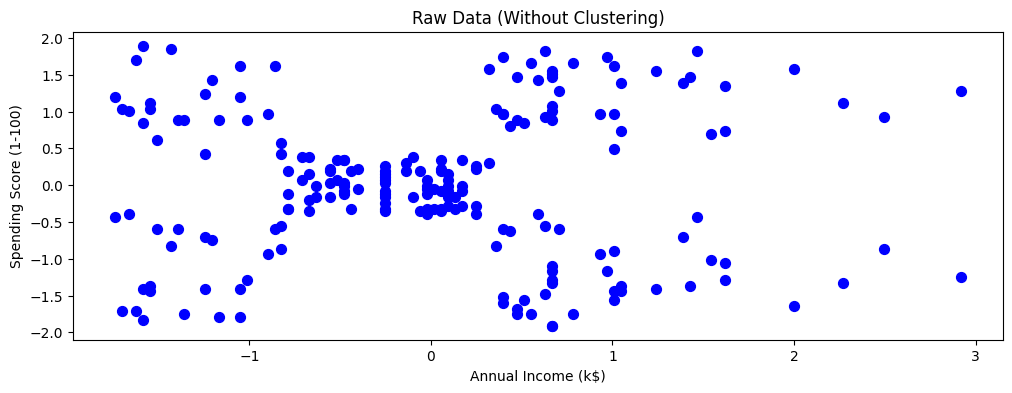

In [41]:
plt.figure(figsize=(12,4))
plt.scatter(df["Annual Income (k$)"],df["Spending Score (1-100)"],c="Blue",marker="o",s=50)
plt.title("Raw Data (Without Clustering)")
plt.xlabel("Annual Income (k$)")
plt.ylabel("Spending Score (1-100)")
plt.show()

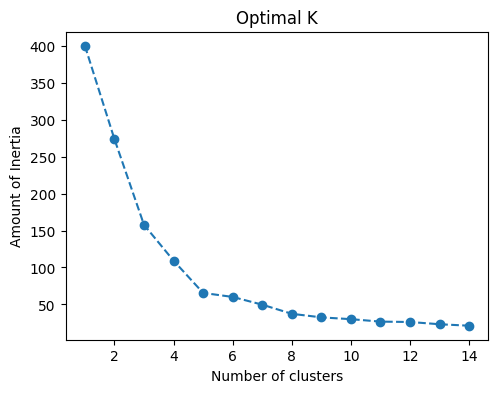

In [42]:
# Step 2 : estimating the no of clusters
wscc=[]
for k in range(1,15):
    kmeans=KMeans(n_clusters=k,init="k-means++",random_state=42)
    kmeans.fit(df)
    inertia=kmeans.inertia_
    wscc.append(inertia)

plt.figure(figsize=(12,4))
plt.subplot(1,2,1)
plt.plot(range(1,15),wscc,marker="o",linestyle="--")
plt.xlabel("Number of clusters")
plt.ylabel("Amount of Inertia")
plt.title("Optimal K")
plt.show()

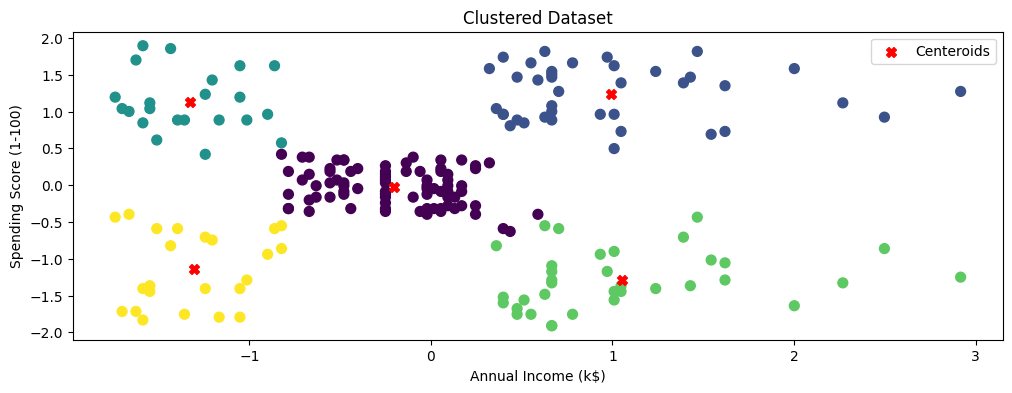

In [54]:
# Step 3 : clustring the data with k=5

kmeans=KMeans(n_clusters=5,init="k-means++",random_state=42)
kmeans.fit(df)
labels=kmeans.predict(df)

plt.figure(figsize=(12,4))
plt.scatter(df["Annual Income (k$)"],df["Spending Score (1-100)"],marker="o",c=labels,cmap="viridis",s=50)
centers=kmeans.cluster_centers_
plt.scatter(centers[:,0],centers[:,1],marker="X",c="red",s=50,label="Centeroids")
plt.legend()
plt.xlabel("Annual Income (k$)")
plt.ylabel("Spending Score (1-100)")
plt.title("Clustered Dataset")
plt.show()



# K-Means Clustering: Quiz & Data Analysis

This document breaks down the fundamental mechanics of K-Means clustering, followed by an analysis of clustered customer data and strategic business recommendations.

---

## Part 1: Quiz Explanation - K-Means Clustering

Below is a review of the statements regarding K-Means clustering:

| Statement | Status | Why? |
| :--- | :--- | :--- |
| **K must be specified by the user before training** | **TRUE** | K-Means is not a "discovery" algorithm for the number of clusters; you have to tell it exactly how many groups ($K$) you want at the start. |
| **K-Means uses Euclidean distance to assign each data point to the nearest centroid** | **TRUE** | The core of the algorithm is calculating the straight-line distance (Euclidean distance) between data points and the center of a cluster (the centroid). |
| **Different random centroid initializations can lead to different final cluster assignments** | **TRUE** | Depending on the lucky or unlucky placement of initial centroids, the algorithm may converge on different local optima. |
| **K-Means always finds the globally optimal clustering solution for any dataset** | **FALSE** | Because the algorithm is greedy, it often gets stuck in local minima and does not guarantee the global optimum. |

---

## Part 2: Customer Segmentation Analysis

Based on the clustered dataset shown in the plot (Annual Income vs. Spending Score), we can define five distinct customer profiles:

### 1. Defining the Profiles
* **Upper-Left (Teal): Low Income, High Spend.** These individuals have lower income scores but very high spending scores.
* **Lower-Left (Yellow): Low Income, Low Spend.** This group is conservative with their money and has limited financial resources.
* **Center (Dark Purple): Average Income, Average Spend.** The "Middle Ground" cluster that represents the standard consumer.
* **Upper-Right (Blue): High Income, High Spend.** The "Whales" or "Target Consumers" who have the means and the desire to spend.
* **Lower-Right (Light Green): High Income, Low Spend.** These are affluent individuals who are likely highly frugal or brand-loyal and difficult to convert.

---

## Part 3: Strategic & Ethical Applications

### 1. Business Strategy: Marketing Approach
If I were the marketing manager, my campaigns would look drastically different for these two specific groups:

* **For "Low Income, High Spend" (Teal Cluster):**
    * **The Hook:** Focus on **aspirational lifestyle** and **instant gratification**.
    * **Strategy:** Use "Buy Now, Pay Later" (BNPL) messaging, flash sales, and trend-focused advertisements. 
    * **Channel:** Social media influencers and high-frequency mobile ads.

* **For "High Income, Low Spend" (Light Green Cluster):**
    * **The Hook:** Focus on **value, exclusivity, and long-term quality**.
    * **Strategy:** These customers aren't moved by cheap discounts. I would use "Investment Piece" messaging, emphasizing the durability or the prestige of the product. 
    * **Channel:** Personalized email marketing, premium loyalty programs, and high-end print or targeted digital media.

### 2. Ethics in Data: High-Interest Credit Offers
**Should we aggressively push high-interest credit to the "Low Income, High Spend" cluster?**

From a purely mathematical or "growth-at-all-costs" business perspective, this cluster is the most likely to take the offer because they clearly have a high propensity to spend beyond their immediate means. 

**However, from an ethical standpoint: No.** * **Predatory Lending:** Targeting a group that already shows signs of financial over-extension (spending high relative to low income) with high-interest debt is often considered predatory. 
* **Long-term Risk:** While it might yield short-term interest profits, it significantly increases the risk of **default**. 
* **Brand Reputation:** In the modern "ESG" (Environmental, Social, and Governance) climate, being seen as an organization that exploits vulnerable spending habits can lead to PR backlash and regulatory scrutiny.

A more ethical approach would be offering this group **budgeting tools** or **discounts on essentials** to build long-term brand loyalty without contributing to a debt spiral.